# 05 - Dataset Design & Quality Control

This notebook inspects the **final V3 clearance-aware dataset** used for surrogate training and evaluation.
It reads the ML-ready artifacts directly from `data/processed/ml` and computes QC summaries in-place.

**Design choices** (see `configs/sim/v3_literature_dataset_spec_clearance.yaml`):

| Parameter | Sampling | Range / Values |
|-----------|----------|----------------|
| `patch_width` | Discrete | 0.25, 0.5, 1.0 |
| `patch_offset` | Discrete | left, center, right |
| `C0` | Uniform | [0.8, 1.2] |
| `decay_rate` | Uniform | [0.05, 0.3] s^-1 |
| `k_dermis` | Discrete | 0, 1e-5, 3.3e-5, 1e-4 s^-1 |
| `heterogeneity_sigma` | Uniform | [0.01, 0.08] |
| `heterogeneity_steps` | Random int | [3, 9] |

**Target split:** 700 train / 150 val / 150 test (seed 321).

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skin_diffusion.notebook_helpers import setup_repo_root

repo_root = setup_repo_root()

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
})

ml_dir = Path('data/processed/ml')
meta = json.load(open(ml_dir / 'meta.json'))
train_data = np.load(ml_dir / 'train.npz')
val_data = np.load(ml_dir / 'val.npz')
test_data = np.load(ml_dir / 'test.npz')

splits = ['train', 'val', 'test']
split_data = {'train': train_data, 'val': val_data, 'test': test_data}
feature_names = meta['feature_names']

# Build a lightweight QC structure directly from current artifacts
counts = {s: int(split_data[s]['X'].shape[0]) for s in splits}
counts['total'] = int(sum(counts[s] for s in splits))

expected_counts = {s: int(meta['splits'][s]['rows']) for s in splits}
actual_counts = {s: counts[s] for s in splits}

def run_dir_set(split_name):
    idx_rows = meta['splits'][split_name].get('index', [])
    return set(row.get('run_dir', '') for row in idx_rows if row.get('run_dir', ''))

run_sets = {s: run_dir_set(s) for s in splits}
overlap = {}
for i, a in enumerate(splits):
    for b in splits[i+1:]:
        overlap_key = f'{a}_{b}'
        overlap[overlap_key] = len(run_sets[a].intersection(run_sets[b]))

def value_counts_from_feature(split_name, feat_name, round_decimals=None):
    fi = feature_names.index(feat_name)
    vals = split_data[split_name]['X'][:, fi]
    if round_decimals is not None:
        vals = np.round(vals, round_decimals)
    uniq, cnt = np.unique(vals, return_counts=True)
    return {str(u): int(c) for u, c in zip(uniq.tolist(), cnt.tolist())}

qc = {
    'counts': counts,
    'checks': {
        'count_match': {'expected': expected_counts, 'actual': actual_counts},
        'overlap': {k: v for k, v in overlap.items() if v > 0},
    },
    'patch_width_counts': {s: value_counts_from_feature(s, 'patch_width', round_decimals=3) for s in splits},
    'patch_offset_counts': {s: value_counts_from_feature(s, 'patch_offset', round_decimals=3) for s in splits},
    'k_dermis_counts': {s: value_counts_from_feature(s, 'k_dermis', round_decimals=8) for s in splits},
}

print('Loaded data/processed/ml artifacts and built QC summaries.')
print(f'Splits: {actual_counts}')
print(f'Features ({len(feature_names)}): {feature_names}')
print(f'Targets: {meta["scalar_target_names"]}')

Loaded data/processed/ml artifacts and built QC summaries.
Splits: {'train': 700, 'val': 150, 'test': 150}
Features (20): ['patch_width', 'patch_offset', 'C0', 'decay_rate', 'k_dermis', 'heterogeneity_sigma', 'heterogeneity_steps', 'dose_proxy_c0_over_decay', 'log_decay_rate', 'width_times_sigma', 'c0_times_width', 'decay_times_width', 'sigma_times_width', 'D_mean', 'D_std', 'D_p10', 'D_p50', 'D_p90', 'D_top_mean', 'D_bottom_mean']
Targets: ['P', 'J_ss', 'J_peak', 't_peak', 'M_delivered_24h']


## 1 - Split counts & overlap check

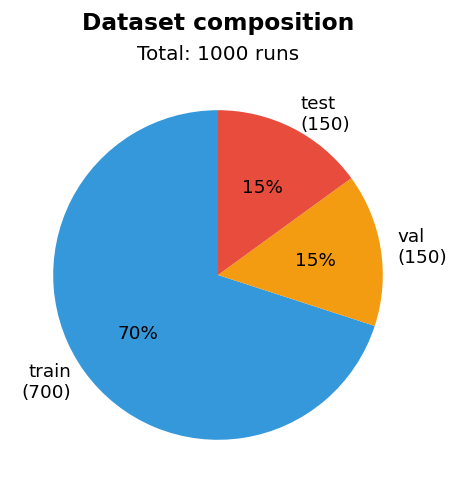

In [8]:
counts = qc['counts']
splits = ['train', 'val', 'test']
sizes = [counts[s] for s in splits]

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
fig.suptitle('Dataset composition', fontsize=14, fontweight='bold')

colours = ['#3498db', '#f39c12', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=[f'{s}\n({n})' for s, n in zip(splits, sizes)],
    colors=colours,
    autopct='%1.0f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
ax.set_title(f'Total: {counts["total"]} runs')

plt.show()

**Breakdown.**

- The split-size plot checks that train/val/test are close to the intended 70/15/15 design.
- The overlap matrix is a leakage check: only diagonal values should be non-zero.
- If this section is clean, downstream model comparisons are statistically valid.


## 2 - Categorical parameter balance

Discrete parameters should be approximately balanced across splits.

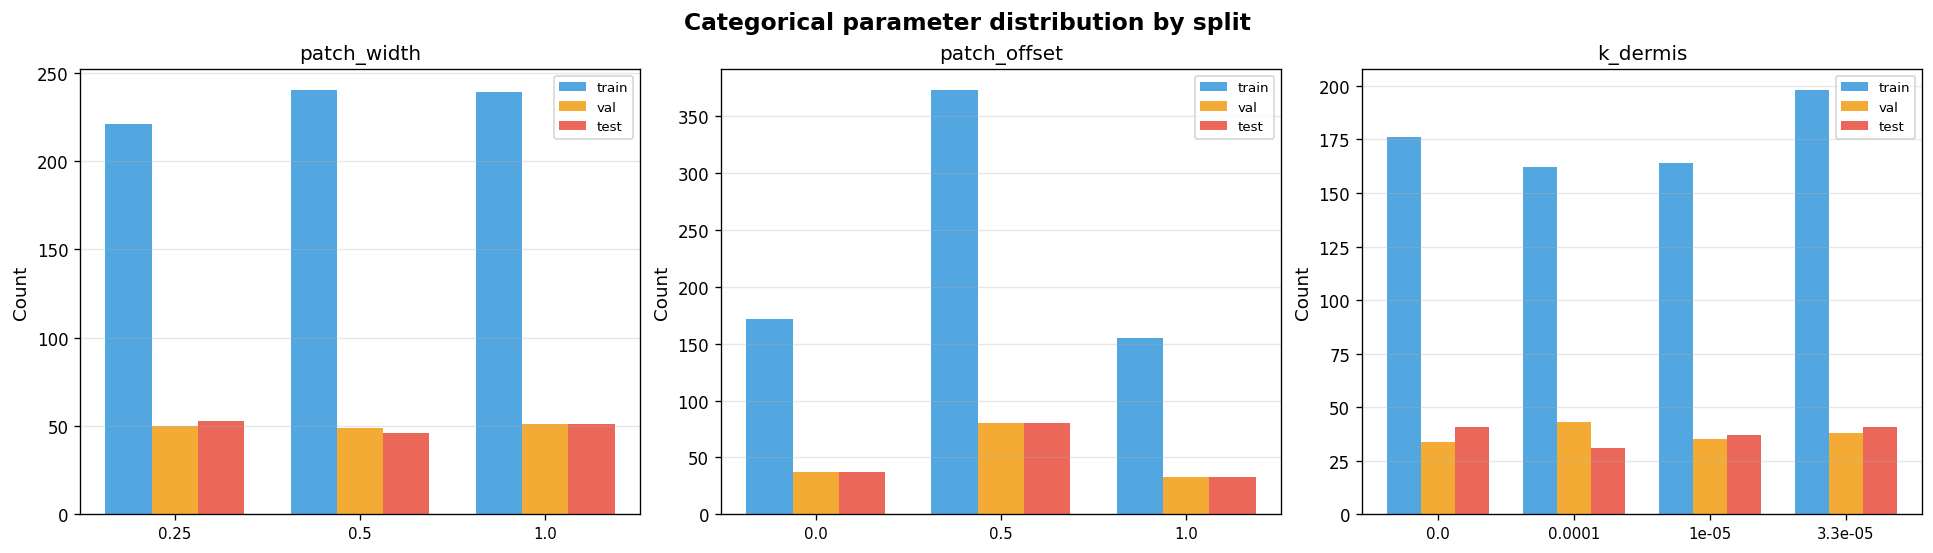

In [3]:
cat_params = [
    ('patch_width', qc['patch_width_counts']),
    ('patch_offset', qc['patch_offset_counts']),
    ('k_dermis', qc['k_dermis_counts']),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
fig.suptitle('Categorical parameter distribution by split', fontsize=14, fontweight='bold')

split_colours = {'train': '#3498db', 'val': '#f39c12', 'test': '#e74c3c'}

for ax, (param_name, param_data) in zip(axes, cat_params):
    categories = sorted(param_data['train'].keys(), key=str)
    x = np.arange(len(categories))
    width = 0.25

    for i, split in enumerate(splits):
        vals = [param_data[split].get(c, 0) for c in categories]
        ax.bar(x + i * width, vals, width, label=split,
               color=split_colours[split], alpha=0.85)

    ax.set_xticks(x + width)
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_title(param_name)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.show()

**Breakdown.**

- These bars verify that discrete design variables are represented across all splits.
- Mild imbalance is acceptable; severe missing categories in val/test would weaken generalisation claims.
- This is especially important for patch geometry and dermal-clearance settings.


## 3 - Continuous parameter distributions

We load the actual feature arrays and plot histograms for each continuous parameter.

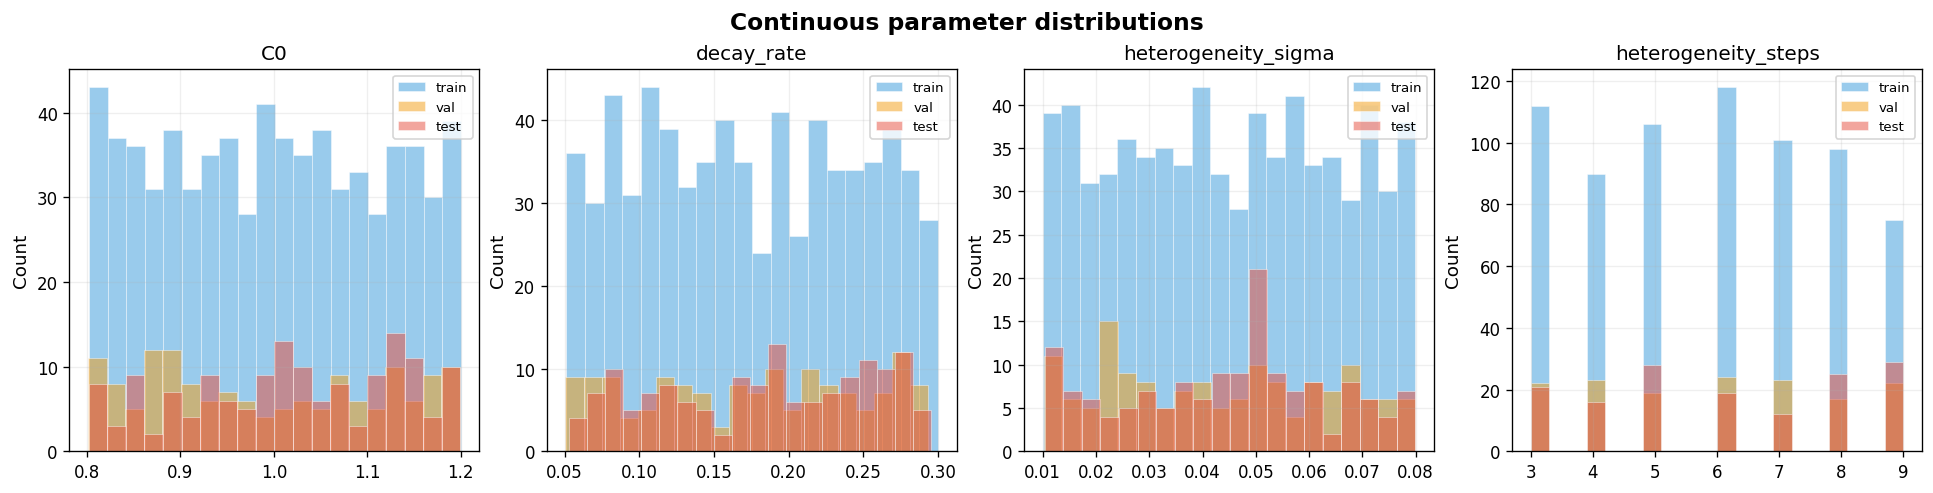

In [4]:
# Use feature arrays already loaded above
feature_names = meta['feature_names']

# Select physically meaningful features (not engineered)
phys_features = ['C0', 'decay_rate', 'heterogeneity_sigma', 'heterogeneity_steps']
phys_idxs = [feature_names.index(f) for f in phys_features if f in feature_names]

fig, axes = plt.subplots(1, len(phys_idxs), figsize=(4 * len(phys_idxs), 4),
                          constrained_layout=True)
fig.suptitle('Continuous parameter distributions', fontsize=14, fontweight='bold')

for ax, fi in zip(axes, phys_idxs):
    fname = feature_names[fi]
    for data, label, c in [(train_data, 'train', '#3498db'),
                            (val_data, 'val', '#f39c12'),
                            (test_data, 'test', '#e74c3c')]:
        ax.hist(data['X'][:, fi], bins=20, alpha=0.5, color=c, label=label,
                edgecolor='white', linewidth=0.5)
    ax.set_title(fname)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.show()

**Breakdown.**

- Histogram overlap across train/val/test indicates whether each split samples the same design space.
- Large shifts would indicate a distribution-mismatch problem rather than a model problem.
- This section supports fair comparison in Notebook 06.


## 4 - Target (output) distributions

The five scalar targets span many orders of magnitude.
Plotting log-scaled distributions helps check coverage and split consistency for surrogate training.

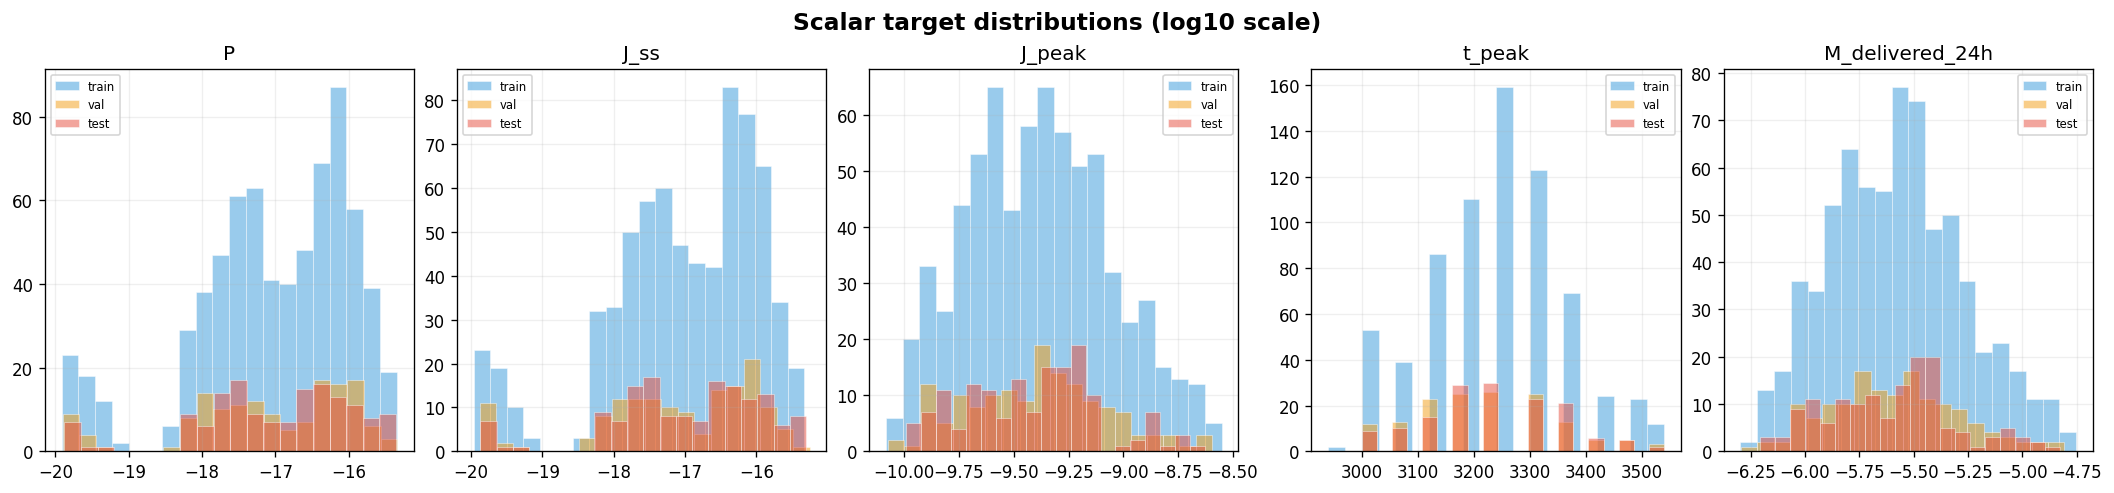

In [5]:
target_names = meta['scalar_target_names']

fig, axes = plt.subplots(1, len(target_names), figsize=(3.5 * len(target_names), 4),
                          constrained_layout=True)
fig.suptitle('Scalar target distributions (log10 scale)', fontsize=14, fontweight='bold')

for ax, ti in zip(axes, range(len(target_names))):
    tname = target_names[ti]
    for data, label, c in [(train_data, 'train', '#3498db'),
                            (val_data, 'val', '#f39c12'),
                            (test_data, 'test', '#e74c3c')]:
        vals = data['y_scalar'][:, ti]
        if tname == 't_peak':
            ax.hist(vals, bins=20, alpha=0.5, color=c, label=label,
                    edgecolor='white', linewidth=0.5)
        else:
            ax.hist(np.log10(np.abs(vals) + 1e-30), bins=20, alpha=0.5,
                    color=c, label=label, edgecolor='white', linewidth=0.5)
    ax.set_title(tname)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

plt.show()

**Breakdown.**

- Log-scaled target plots confirm dynamic range and highlight whether tails are represented.
- Similar train/val/test target distributions reduce risk of optimistic or pessimistic evaluation bias.
- This section explains why relative and log-aware error metrics are used later.


## 5 - Flux curve diversity

A random sample of flux curves from the training set, coloured by `patch_width`,
shows the rich variety the surrogates must capture.

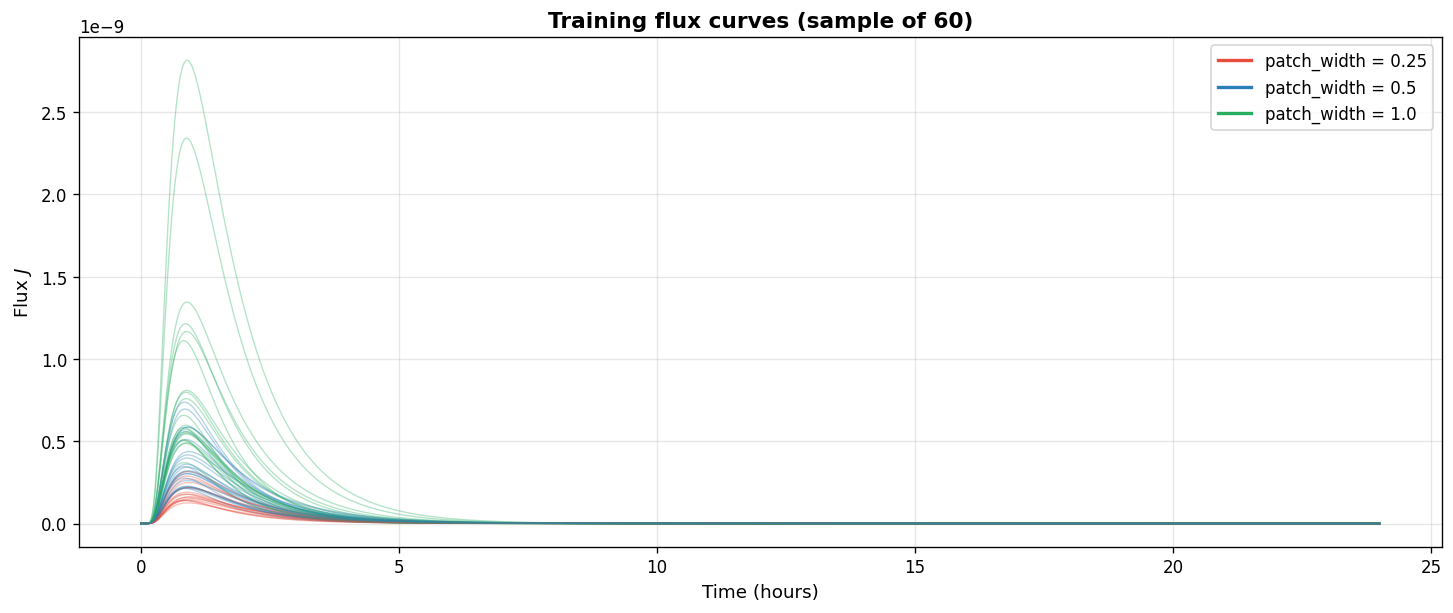

In [6]:
pw_idx = feature_names.index('patch_width')
pw_map = {0.25: '#e74c3c', 0.5: '#2980b9', 1.0: '#27ae60'}

rng = np.random.default_rng(42)
sample_idxs = rng.choice(train_data['J'].shape[0], size=60, replace=False)

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.set_title('Training flux curves (sample of 60)', fontsize=13, fontweight='bold')

for i in sample_idxs:
    t_h = train_data['t'][i] / 3600.0
    J_i = train_data['J'][i]
    pw = train_data['X'][i, pw_idx]
    # Find closest key
    closest_pw = min(pw_map.keys(), key=lambda k: abs(k - pw))
    ax.plot(t_h, J_i, alpha=0.35, lw=0.8, color=pw_map[closest_pw])

# Legend
for pw_val, c in pw_map.items():
    ax.plot([], [], color=c, lw=2, label=f'patch_width = {pw_val}')
ax.legend(fontsize=10)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Flux $J$')
ax.grid(alpha=0.3)
plt.show()

**Breakdown.**

- The sampled curves show that the dataset is not a single-shape fitting problem.
- Variation in amplitude, rise time, and peak timing motivates both curve-level metrics and scalar summaries.
- Colouring by patch width gives a quick visual cue that geometry drives part of this diversity.


## 6 - Feature engineering summary

Beyond the 7 physical parameters, 13 engineered features capture interaction effects
and diffusivity statistics.

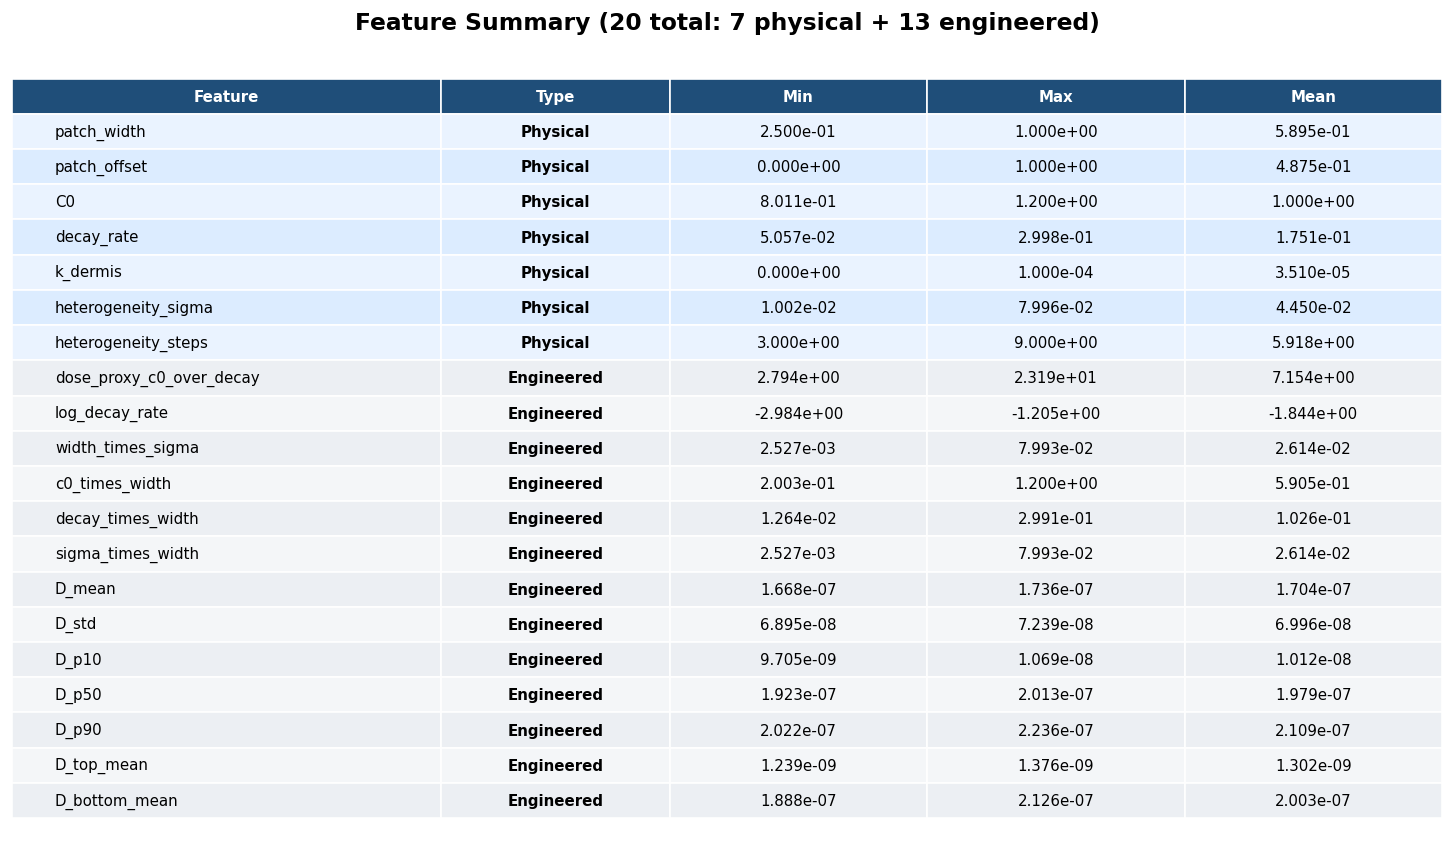

In [9]:
phys = feature_names[:7]
eng = feature_names[7:]

# Build table rows with split-aware styling metadata
table_rows = []
for i, feat_name in enumerate(feature_names):
    feat_type = 'Physical' if feat_name in phys else 'Engineered'
    values_all = np.concatenate([
        train_data['X'][:, i],
        val_data['X'][:, i],
        test_data['X'][:, i],
    ])
    table_rows.append([
        feat_name,
        feat_type,
        f'{values_all.min():.3e}',
        f'{values_all.max():.3e}',
        f'{values_all.mean():.3e}',
    ])

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
ax.axis('off')

table = ax.table(
    cellText=table_rows,
    colLabels=['Feature', 'Type', 'Min', 'Max', 'Mean'],
    colLoc='center',
    cellLoc='center',
    loc='center',
    colWidths=[0.30, 0.16, 0.18, 0.18, 0.18],
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.45)

# Header styling
header_color = '#1f4e79'
for col in range(5):
    cell = table[(0, col)]
    cell.set_facecolor(header_color)
    cell.set_edgecolor('white')
    cell.get_text().set_color('white')
    cell.get_text().set_weight('bold')

# Body styling: shade by feature type, subtle zebra within each type
for row_idx, row_vals in enumerate(table_rows, start=1):
    feat_type = row_vals[1]
    if feat_type == 'Physical':
        base = '#eaf3ff'
        alt = '#dcecff'
    else:
        base = '#f4f6f8'
        alt = '#eceff3'
    row_color = base if row_idx % 2 else alt

    for col in range(5):
        cell = table[(row_idx, col)]
        cell.set_facecolor(row_color)
        cell.set_edgecolor('white')
        if col == 0:
            cell.get_text().set_ha('left')
        if col == 1:
            cell.get_text().set_weight('bold')

ax.set_title(
    f'Feature Summary ({len(feature_names)} total: {len(phys)} physical + {len(eng)} engineered)',
    fontsize=14,
    fontweight='bold',
    pad=16,
)

plt.show()

**Breakdown.**

- The table separates physical inputs from engineered inputs and documents their ranges.
- This makes the model input space auditable for the thesis and easier to justify in methods text.
- Keep this as the reference cell when describing the final ML feature set.
